In [1]:
#!pip install -qq dtreeviz
import os, sys
sys.path.append(f"{os.getcwd()}/../")

In [2]:
# Import the main packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dtreeviz
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier


%matplotlib inline

from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

In [3]:
# Read the dataset and take a quick look
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
### edTest(test_assign) ###
# Assign the predictor and response variables. 
# "Outcome" is the response and all the other columns are the predictors
X = df.drop('Outcome', axis=1) 
y = df['Outcome']  


In [7]:
# Fix a random_state
random_state = 144

# Split the data into train and validation sets with 80% train size
# and the above set random state
X_train, X_val, y_train,y_val = train_test_split(X, y, train_size=0.8, random_state=random_state)


## Bagging Implementation

In [9]:
# Define a Bagging classifier with randon_state as above
# and with a DecisionClassifier as a basemodel
# Fix the max_depth variable to 20 for all trees
max_depth = 20

# Set the 1000 estimators
n_estimators = 1000

# Initialize the Decision Tree classsifier with the set max depth and 
# random state
basemodel = DecisionTreeClassifier(
    max_depth=max_depth, random_state=random_state
)

# Initialize a Bagging classsifier with the Decision Tree as the base and 
# estimator and the number of estimator defined above
bagging = BaggingClassifier(
    estimator=basemodel,
    n_estimators=n_estimators,
    random_state=random_state
)

# Fit the Bagging model on the training set
bagging.fit(X_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...dom_state=144)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",144
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [10]:
### edTest(test_bagging) ###

# Use the trained model to predict on the validation data
predictions = bagging.predict(X_val)

# Compute the accuracy on the validation set
acc_bag = round(accuracy_score(predictions, y_val),2)

# Print the validation data accuracy
print(f'For Bagging, the accuracy on the validation set is {acc_bag}')


For Bagging, the accuracy on the validation set is 0.76


## Random Forest implementation

In [13]:
# Define a Random Forest classifier with random_state as defined above
#  and set the maximum depth to be max_depth and use 1000 estimators
random_forest = RandomForestClassifier(
    max_depth=max_depth,
    n_estimators=n_estimators,
    random_state=random_state
)

# Fit the model on the training set
random_forest.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",144
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [14]:
### edTest(test_RF) ###

# Use the trained Random Forest model to predict on the validation data
predictions = random_forest.predict(X_val)

# Compute the accuracy on the validation set
acc_rf = round(accuracy_score(predictions, y_val),2)

# Print the validation data accuracy
print(f'For Random Forest, the accuracy on the validation set is {acc_rf}')


For Random Forest, the accuracy on the validation set is 0.79


## Visualizing the trees - Bagging

In [15]:
# Helper code to visualize the Bagging tree
# Reduce the max_depth for better visualization 
max_depth = 3

basemodel = DecisionTreeClassifier(max_depth=max_depth, 
                                random_state=random_state)

bagging = BaggingClassifier(estimator=basemodel, 
                                n_estimators=1000)

# Fit the model on the training set
bagging.fit(X_train, y_train)

# Selecting two trees at random
bagvati1 = bagging.estimators_[0]
bagvati2 = bagging.estimators_[100]


In [16]:
vizA = dtreeviz.model(bagvati1, df.iloc[:,:8],df.Outcome,
               feature_names = df.columns[:8],
               target_name = 'Diabetes', class_names= ['No','Yes'],
               )

viz_params = {'fontname': 'monospace',
              'label_fontsize': 18,
              'ticks_fontsize': 16,
              'scale': 1.4}

vizA.view(**viz_params);

In [17]:
vizB = dtreeviz.model(bagvati2, df.iloc[:,:8],df.Outcome,
               feature_names = df.columns[:8],
               target_name = 'Diabetes', class_names= ['No','Yes']
               )
vizB.view(**viz_params);

## Visualizing the trees - Random Forest

In [18]:
# Helper code to visualize the Random Forest tree

# Reduce the max_depth for visualization 
max_depth = 3
random_forest = RandomForestClassifier(max_depth=max_depth, random_state=random_state, n_estimators=1000,max_features = "sqrt")

# Fit the model on the training set
random_forest.fit(X_train, y_train)

# Selecting two trees at random
forestvati1 = random_forest.estimators_[0]
forestvati2 = random_forest.estimators_[100]


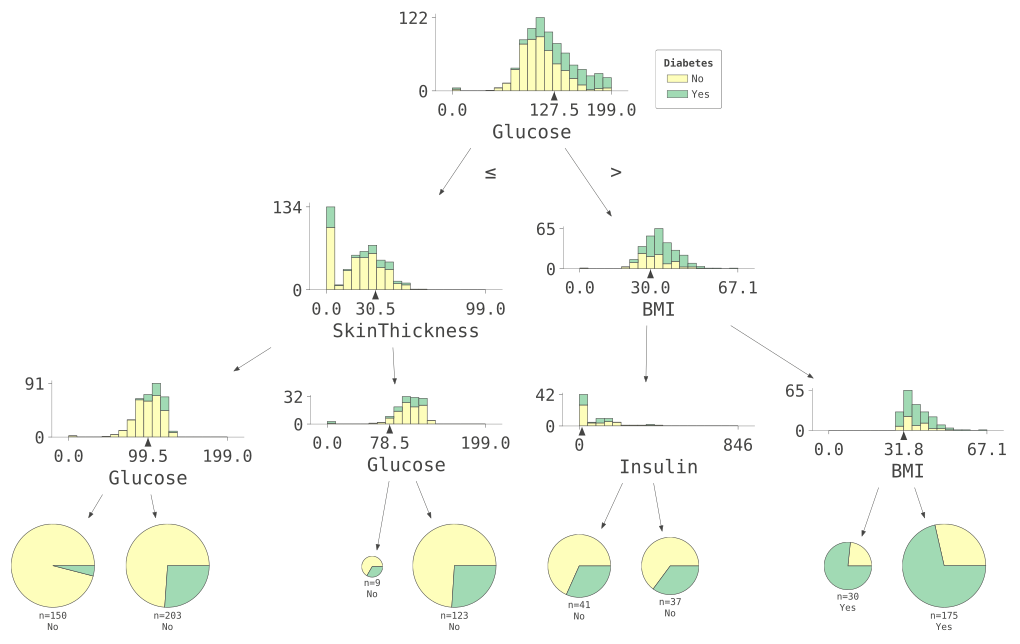

In [19]:
vizC = dtreeviz.model(forestvati1, df.iloc[:,:8],df.Outcome,
               feature_names = df.columns[:8],
               target_name = 'Diabetes', class_names= ['No','Yes']
               )
vizC.view(**viz_params)

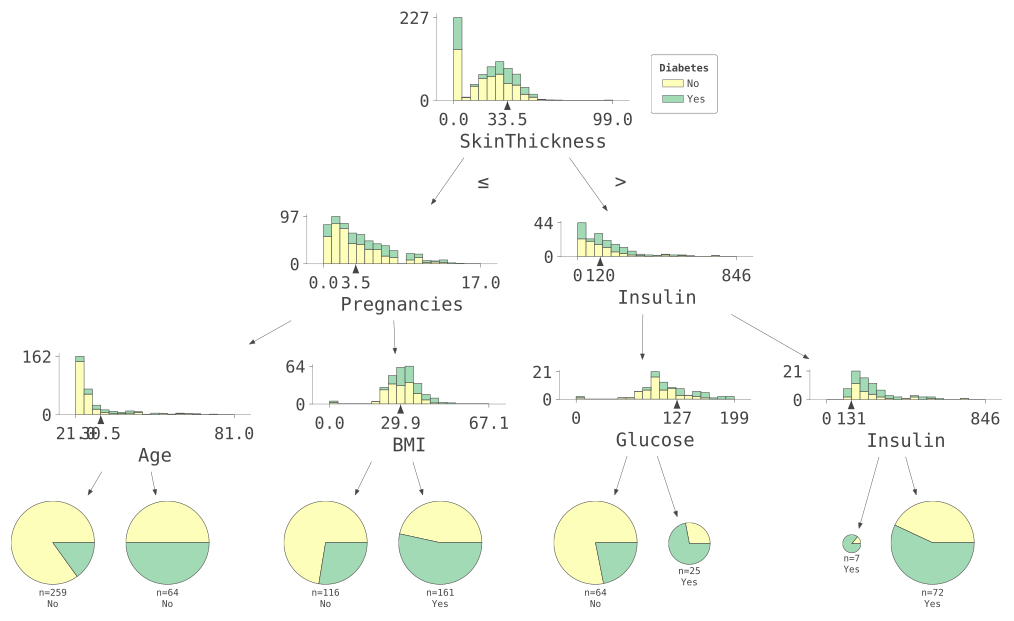

In [20]:
vizD = dtreeviz.model(forestvati2, df.iloc[:,:8],df.Outcome,
               feature_names = df.columns[:8],
               target_name = 'Diabetes', class_names= ['No','Yes']
               )
vizD.view(**viz_params)